# **Importing the necessary libraries**

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import IsolationForest
from keras.models import Model
from keras.layers import Input, Dense
from keras import regularizers

import warnings
warnings.filterwarnings('ignore')

# **Predictive Maintenance Data Exploration**

In [ ]:
# Load the dataset
Maintenance_data = pd.read_csv('/content/predictive-maintenance-dataset.csv', delimiter=';')

In [ ]:
# Display first few rows of the dataset
Maintenance_data.head()

,ball-bearing,humidity,vibration
0,93.744,73.999,18
1,93.74,73.999,18.001
2,93.736,73.998,18.002
3,93.732,73.998,18.003
4,93.729,73.998,18.004


In [ ]:
Maintenance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112001 entries, 0 to 112000
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ball-bearing  112001 non-null  object 
 1   humidity      112001 non-null  float64
 2   vibration     112001 non-null  object 
dtypes: float64(1), object(2)
memory usage: 2.6+ MB


In [ ]:
# Check for missing values
Maintenance_data.isnull().sum()

,0
ball-bearing,0
humidity,0
vibration,0


In [ ]:
Maintenance_data.shape

(112001, 3)

# **Data Pre-processing Steps**

In [ ]:
# Convert 'ball-bearing' and 'vibration' to numeric, coercing errors
Maintenance_data['ball-bearing'] = pd.to_numeric(Maintenance_data['ball-bearing'], errors='coerce')
Maintenance_data['vibration'] = pd.to_numeric(Maintenance_data['vibration'], errors='coerce')

Maintenance_data['ball-bearing'].fillna(Maintenance_data['ball-bearing'].mean(), inplace=True)
Maintenance_data['vibration'].fillna(Maintenance_data['vibration'].mean(), inplace=True)

vibration_threshold = Maintenance_data['vibration'].mean() + 2 * Maintenance_data['vibration'].std()
Maintenance_data['target'] = (Maintenance_data['vibration'] > vibration_threshold).astype(int)

X = Maintenance_data[['ball-bearing', 'humidity', 'vibration']]
y = Maintenance_data['target']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Data Visualizations**

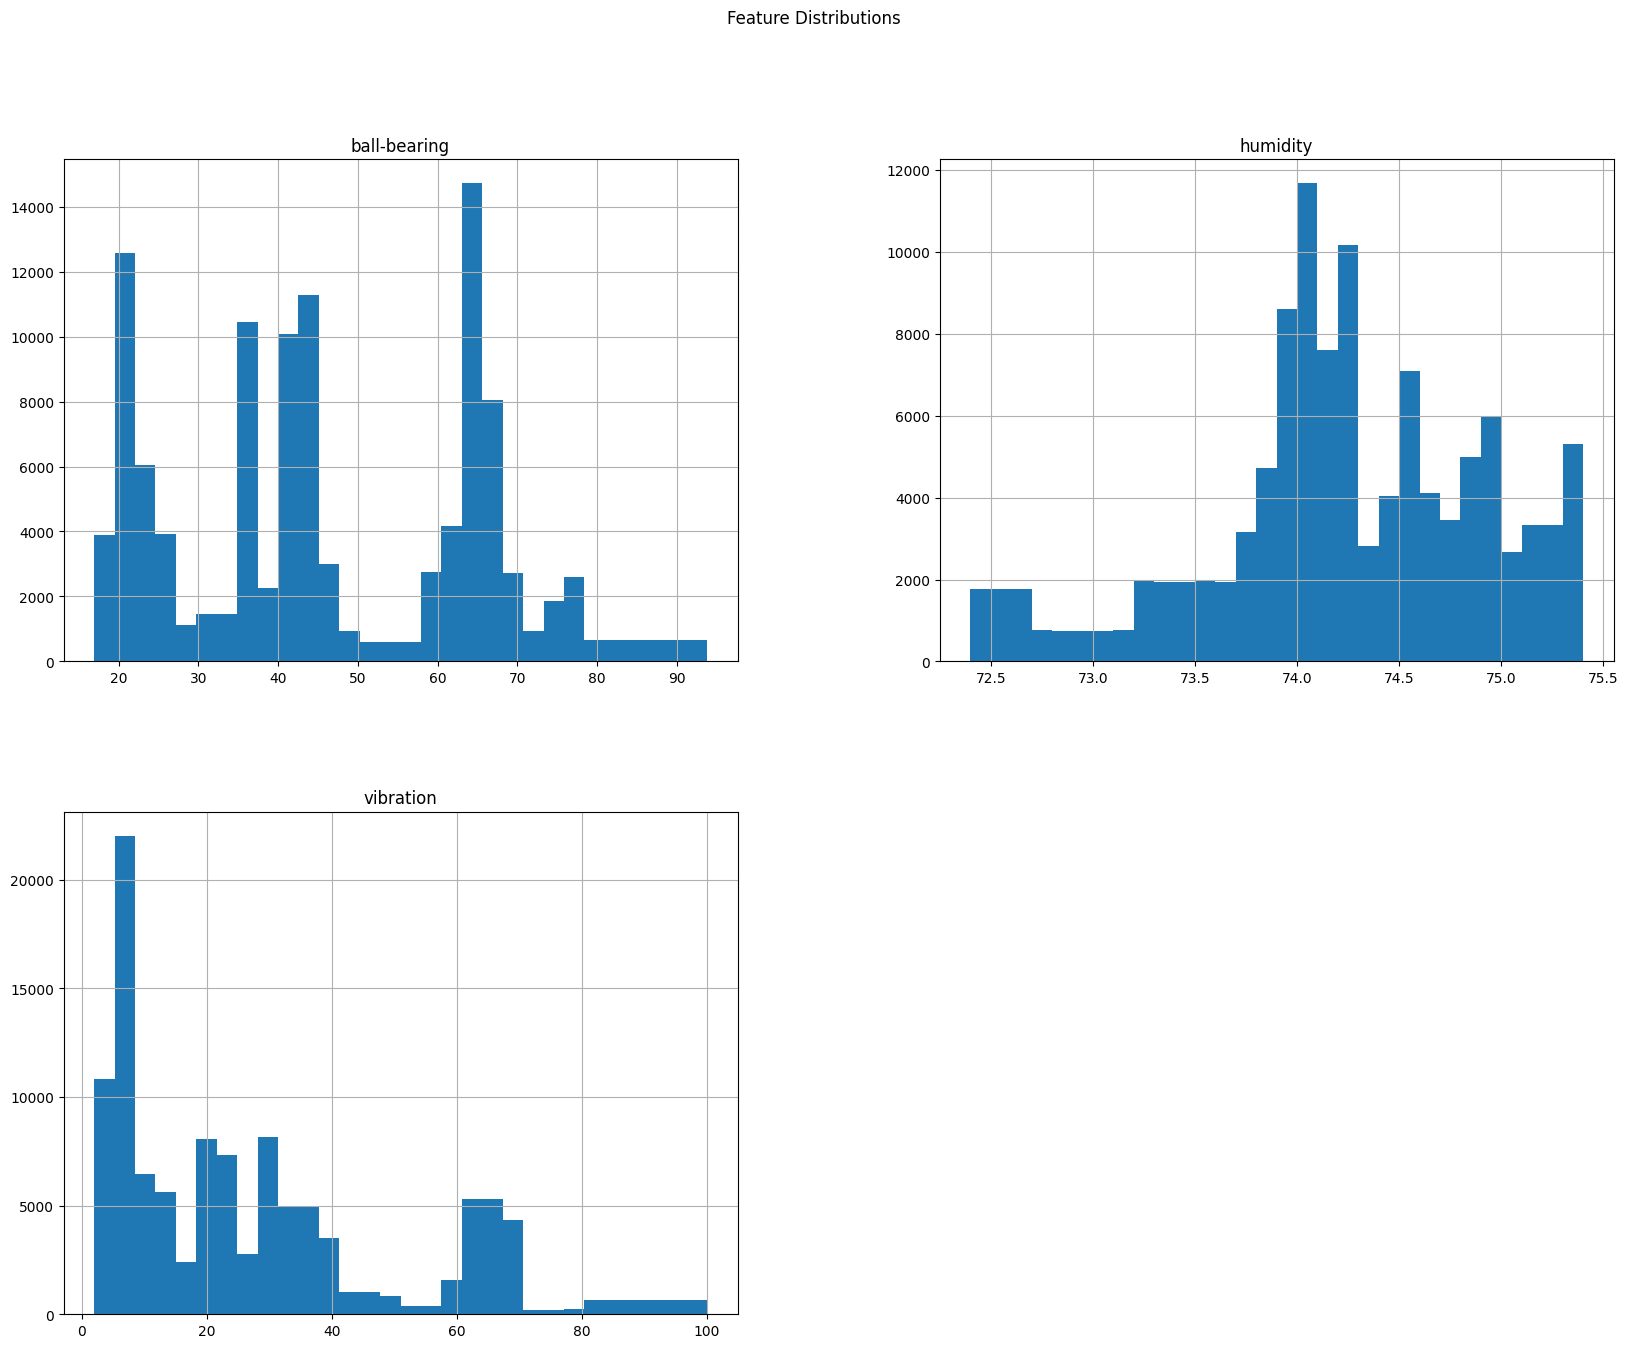

In [ ]:
# Distribution of Features
X.hist(bins=30, figsize=(20, 15))
plt.suptitle("Feature Distributions")
plt.show()

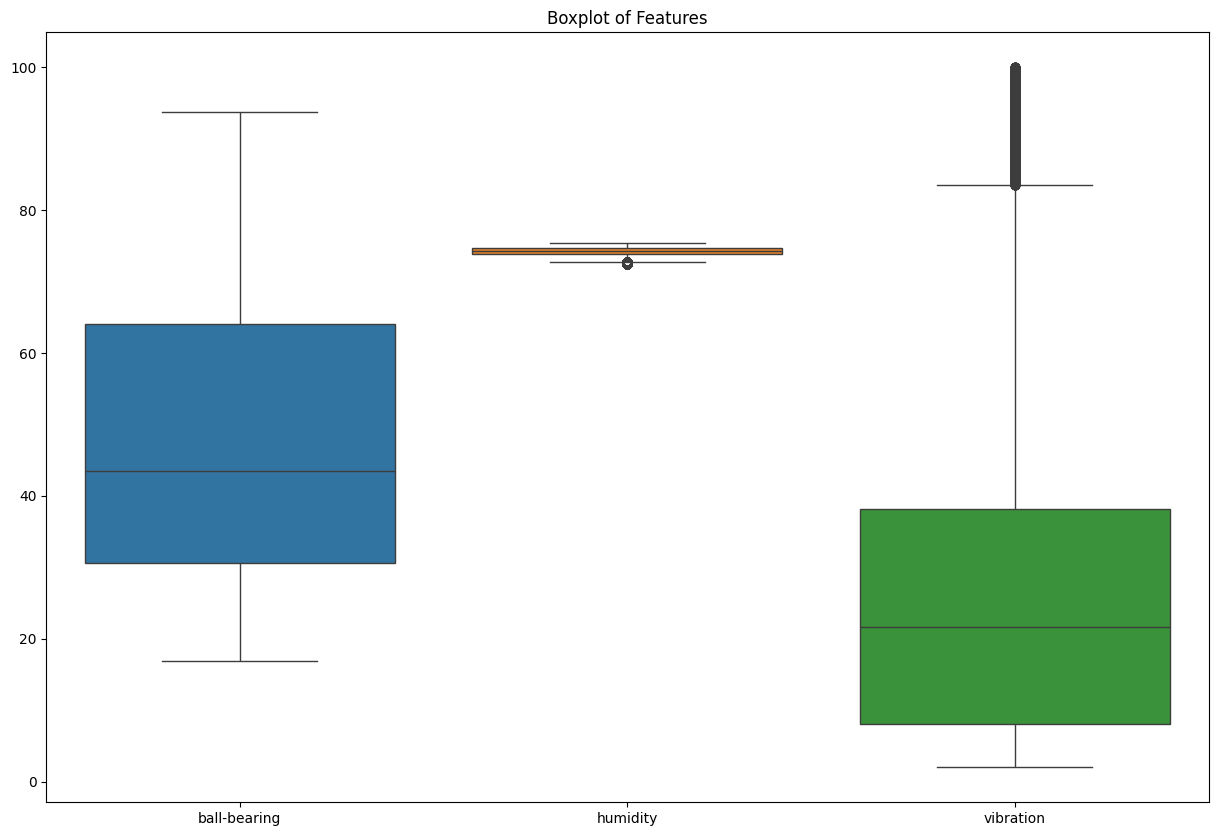

In [ ]:
# Boxplot of features
plt.figure(figsize=(15, 10))
sns.boxplot(data=X)
plt.title("Boxplot of Features")
plt.show()

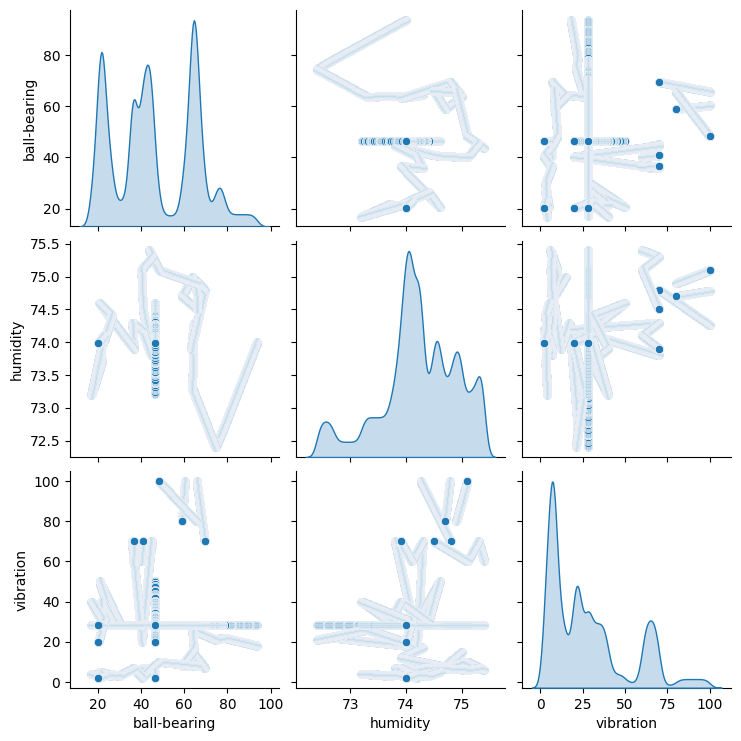

In [ ]:
# Pairplot of Features
sns.pairplot(Maintenance_data[['ball-bearing', 'humidity', 'vibration']], diag_kind='kde')
plt.show()

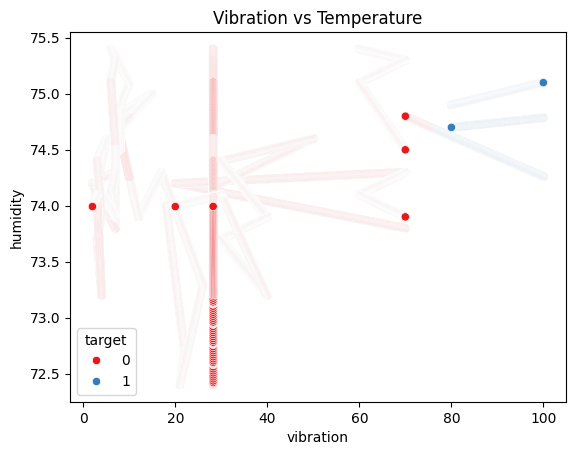

In [ ]:
# Scatter plot for Vibration vs Temperature
sns.scatterplot(x=Maintenance_data['vibration'], y=Maintenance_data['humidity'], hue=Maintenance_data['target'], palette="Set1")
plt.title("Vibration vs Temperature")
plt.show()

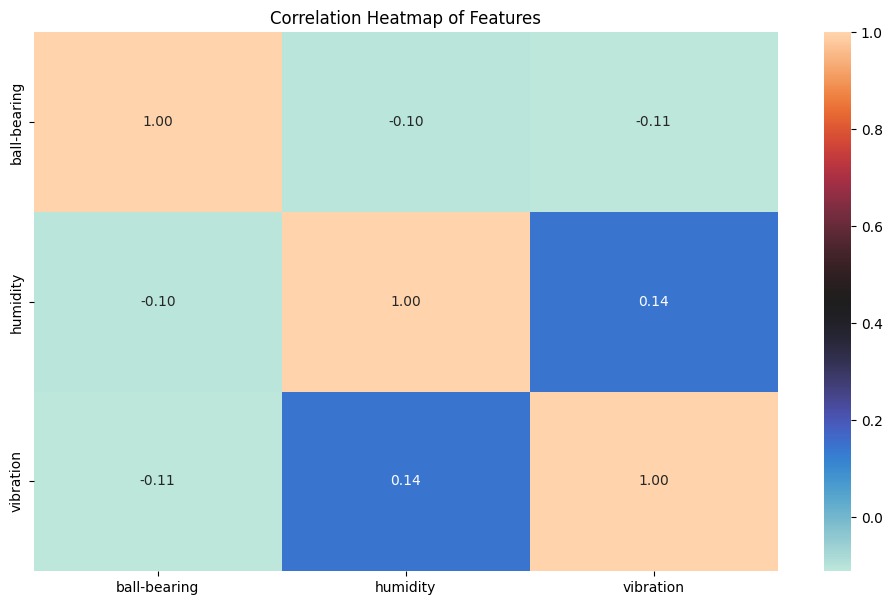

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(X.corr(), annot=True, cmap='icefire', fmt='.2f')
plt.title("Correlation Heatmap of Features")
plt.show()

# **Hypothesis Testing**

In [ ]:
from scipy import stats

# Hypothesis Testing
group1 = Maintenance_data[Maintenance_data['target'] == 0]['vibration']
group2 = Maintenance_data[Maintenance_data['target'] == 1]['vibration']

t_stat, p_value = stats.ttest_ind(group1, group2)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -203.27891857447966, P-value: 0.0


### **p-value < 0.05, reject the null hypothesis**

# **ANOVA Test**

In [ ]:
# ANOVA Test for multiple groups
anova_result = stats.f_oneway(group1, group2)
print(f"ANOVA Test result: {anova_result}")

ANOVA Test result: F_onewayResult(statistic=np.float64(41322.31873680988), pvalue=np.float64(0.0))


# **Model Training and Evaluation**

## **Linear Regression Model**

In [ ]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation metrics for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MAE: {mae_lr}, MSE: {mse_lr}, R2: {r2_lr}")

Linear Regression MAE: 0.09052213463985823, MSE: 0.025099583053521984, R2: 0.3261285550484203


## **Decision Tree Regression**

In [ ]:
# Decision Tree Regression Model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
# Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation metrics for Decision Tree Regression
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree MAE: {mae_dt}, MSE: {mse_dt}, R2: {r2_dt}")

Decision Tree MAE: 0.0, MSE: 0.0, R2: 1.0


## **Lasso Regression**

In [ ]:
# Lasso Regression Model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)

In [ ]:
# Make predictions
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Evaluation metrics for Lasso Regression
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression MAE: {mae_lasso}, MSE: {mse_lasso}, R2: {r2_lasso}")

Lasso Regression MAE: 0.07442138632361268, MSE: 0.037225353122042316, R2: 0.0005769241786867108


# **Model Evaluation Plots**

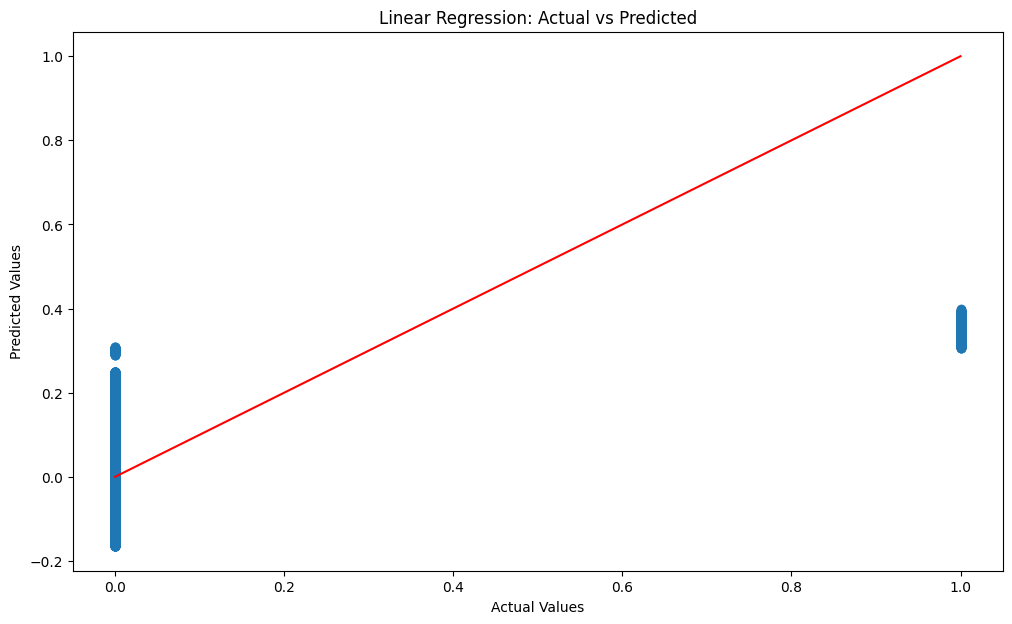

In [ ]:
# Linear Regression: Plot Actual vs Predicted values
plt.figure(figsize=(12, 7))
plt.scatter(y_test, y_pred_lr)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

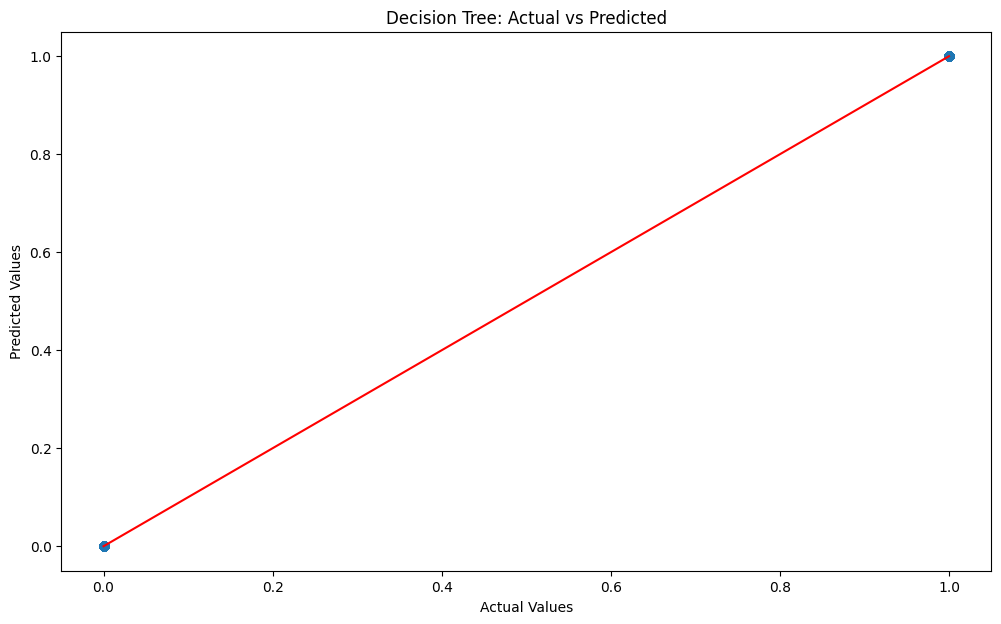

In [ ]:
# Decision Tree: Plot Actual vs Predicted values
plt.figure(figsize=(12, 7))
plt.scatter(y_test, y_pred_dt)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

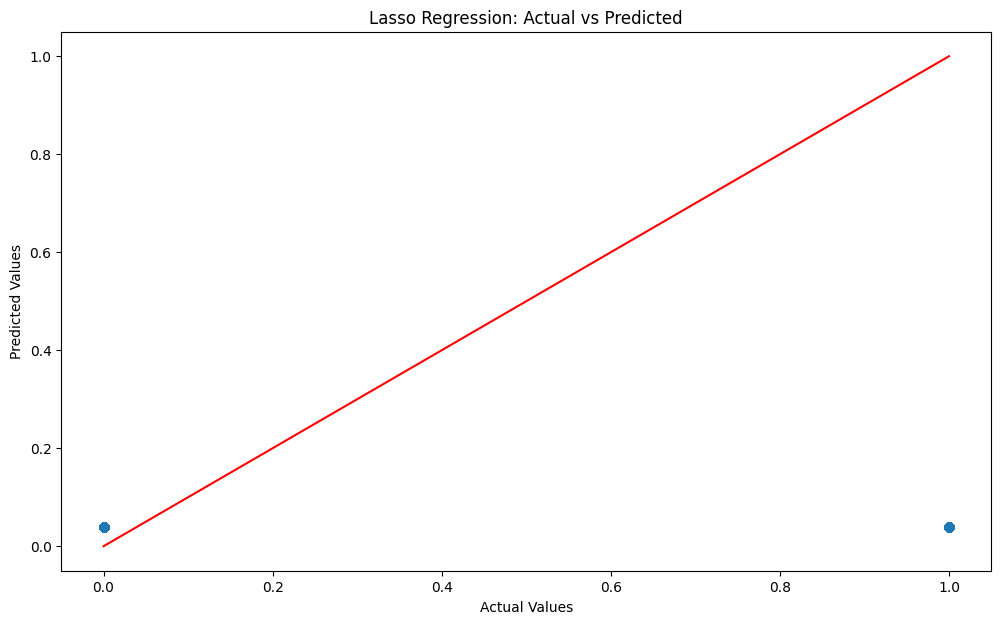

In [ ]:
# Lasso Regression: Plot Actual vs Predicted values
plt.figure(figsize=(12, 7))
plt.scatter(y_test, y_pred_lasso)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title("Lasso Regression: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

In [ ]:
# Linear Regression model
lr_model = LinearRegression()

# Perform 5-fold cross-validation
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Print the cross-validation results
print(f"Linear Regression Cross-Validation Mean MSE: {-cv_scores_lr.mean()}")

Linear Regression Cross-Validation Mean MSE: 0.02505105670644874


In [ ]:
# Decision Tree Regression model
dt_model = DecisionTreeRegressor(random_state=42)

# Perform 5-fold cross-validation
cv_scores_dt = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Print the cross-validation results
print(f"Decision Tree Regression Cross-Validation Mean MSE: {-cv_scores_dt.mean()}")

Decision Tree Regression Cross-Validation Mean MSE: 2.232142857142857e-05


In [ ]:
# Lasso Regression model
lasso_model = Lasso(alpha=0.1)

# Perform 5-fold cross-validation
cv_scores_lasso = cross_val_score(lasso_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

# Print the cross-validation results
print(f"Lasso Regression Cross-Validation Mean MSE: {-cv_scores_lasso.mean()}")

Lasso Regression Cross-Validation Mean MSE: 0.03708878364850158


# **Isolation Forest**

In [ ]:
# Initialize Isolation Forest model
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # contamination is the expected anomaly rate

# Fit the model to the data
iso_forest.fit(X_train_scaled)

IsolationForest(contamination=0.05, random_state=42)

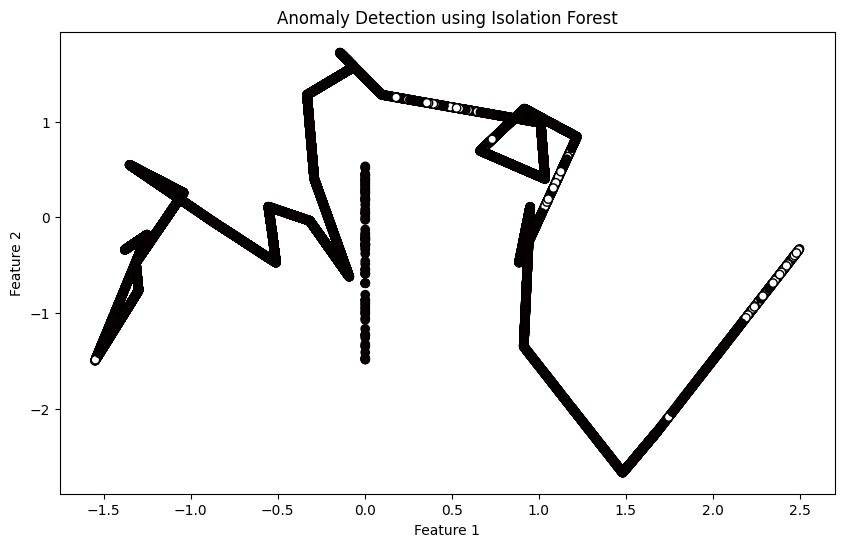

In [ ]:
# Predict anomalies (1 for normal, -1 for anomaly)
y_pred_iso = iso_forest.predict(X_test_scaled)

# Convert predictions to binary (1 = normal, 0 = anomaly)
y_pred_iso = np.where(y_pred_iso == 1, 0, 1)

# Visualizing the anomalies
plt.figure(figsize=(10, 6))
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_pred_iso, cmap='hot', edgecolors='k')
plt.title("Anomaly Detection using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# Print anomaly detection report
print(f"Number of anomalies detected: {np.sum(y_pred_iso)}")

Number of anomalies detected: 1132


# **Autoencoders for Anomaly Detection**

## **Build and Train the Autoencoder Model**

In [ ]:
# Define Autoencoder architecture
input_dim = X_train_scaled.shape[1]  # Number of features

# Define the size of the encoded representation (latent space)
encoding_dim = 2

# Input layer
input_layer = Input(shape=(input_dim,))

# Encoder layers
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder layers
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Train the Autoencoder
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=50, batch_size=256, validation_split=0.2, verbose=1)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9951 - val_loss: 0.9331
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8902 - val_loss: 0.8668
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8320 - val_loss: 0.8059
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7749 - val_loss: 0.7552
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7356 - val_loss: 0.7246
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7101 - val_loss: 0.7036
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6919 - val_loss: 0.6881
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6777 - val_loss: 0.6754
Epoch 9/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6653 - val_loss: 0.6631
Epoch 10/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6519 - val_loss: 0.6486
Epoch 11/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6344 - val_loss: 0.6283
Epoch 12/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

701/701 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


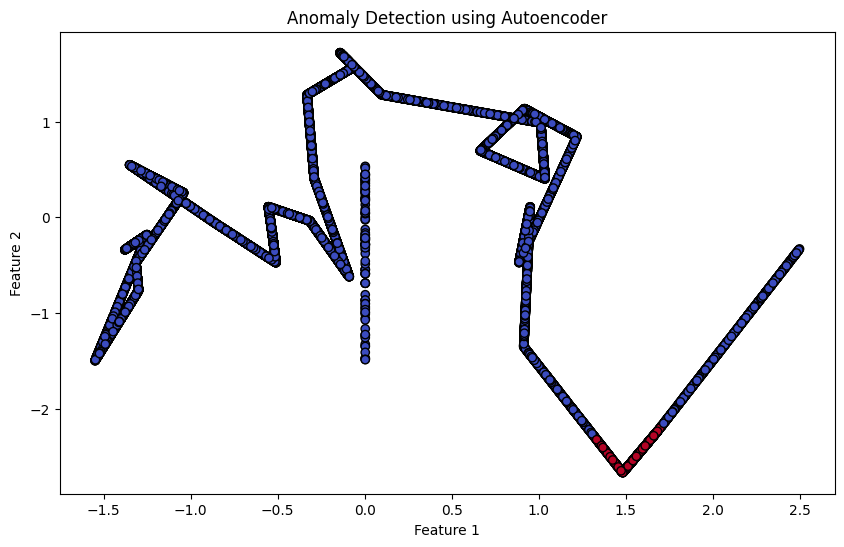

In [ ]:
# Get predictions (reconstructed data)
X_test_pred = autoencoder.predict(X_test_scaled)

# Calculate the reconstruction error (MSE between original and reconstructed)
reconstruction_error = np.mean(np.power(X_test_scaled - X_test_pred, 2), axis=1)

# Define a threshold for anomaly detection
threshold = np.percentile(reconstruction_error, 95)  # Anomalies are in the top 5% of errors

# Predict anomalies
y_pred_ae = np.where(reconstruction_error > threshold, 1, 0)  # 1 = anomaly, 0 = normal

# Visualizing anomalies
plt.figure(figsize=(10, 6))
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_pred_ae, cmap='coolwarm', edgecolors='k')
plt.title("Anomaly Detection using Autoencoder")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# Print anomaly detection report
print(f"Number of anomalies detected: {np.sum(y_pred_ae)}")

Number of anomalies detected: 1120
